# exploratory analysis

## objective

this notebook explores historical stock performance for eight leading technology companies.

the analysis focuses on:

- cumulative returns
- daily returns
- volatility
- descriptive statistics
- company comparisons

the results provide the foundation for the later discussion of investment risk and market behavior.

In [6]:
import plotly.graph_objects as go

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stock_data = pd.read_csv(
    "../data/raw/stock_data.csv",
    header=[0,1],
    index_col=0,
    parse_dates=True
)

metadata = pd.read_csv(
    "../data/processed/company_metadata.csv"
)

stock_data.head()

Ticker     PLTR                              AMD                        \
Price      Open High Low Close Volume       Open       High        Low   
Date                                                                     
2020-01-02  NaN  NaN NaN   NaN    NaN  46.860001  49.250000  46.630001   
2020-01-03  NaN  NaN NaN   NaN    NaN  48.029999  49.389999  47.540001   
2020-01-06  NaN  NaN NaN   NaN    NaN  48.020000  48.860001  47.860001   
2020-01-07  NaN  NaN NaN   NaN    NaN  49.349998  49.389999  48.040001   
2020-01-08  NaN  NaN NaN   NaN    NaN  47.849998  48.299999  47.139999   

Ticker                           ...      NVDA                                \
Price           Close    Volume  ...      Open      High       Low     Close   
Date                             ...                                           
2020-01-02  49.099998  80331100  ...  5.934969  5.963804  5.884506  5.963804   
2020-01-03  48.599998  73127400  ...  5.844234  5.912098  5.819375  5.868347   
2020-01-06  48.389999  47934900  ...  5.775127  5.898177  5.749026  5.892956   
2020-01-07  48.250000  58061400  ...  5.921295  6.010040  5.876301  5.964300   
2020-01-08  47.830002  53767000  ...  5.960075  6.016752  5.920053  5.975487   

Ticker                       MSFT                                      \
Price          Volume        Open        High         Low       Close   
Date                                                                    
2020-01-02  237536000  150.090263  151.933540  149.664893  151.829559   
2020-01-03  205384000  149.655425  151.196208  149.409646  149.938995   
2020-01-06  262636000  148.483276  150.392729  147.944465  150.326553   
2020-01-07  314856000  150.600726  150.931563  148.710182  148.955948   
2020-01-08  277108000  150.232049  151.999717  149.305686  151.328568   

Ticker                
Price         Volume  
Date                  
2020-01-02  22622100  
2020-01-03  21116200  
2020-01-06  20813700  
2020-01-07  21634100  
2020-01-08  27746500  

[5 rows x 40 columns]

In [8]:
# adjusted closing prices

close_prices = stock_data.xs("Close", axis=1, level=1)

close_prices.head()

Ticker,PLTR,AMD,META,GOOGL,TSLA,AAPL,NVDA,MSFT
Date,,,,,,,,
2020-01-02,NaN,49.099998,207.953842,67.832504,28.684000,72.271545,5.963804,151.829559
2020-01-03,NaN,48.599998,206.853500,67.477661,29.534000,71.568924,5.868347,149.938995
2020-01-06,NaN,48.389999,210.749298,69.276215,30.102667,72.139191,5.892956,150.326553
2020-01-07,NaN,48.250000,211.205276,69.142395,31.270666,71.799911,5.964300,148.955948
2020-01-08,NaN,47.830002,213.346481,69.634544,32.809334,72.954933,5.975487,151.328568


In [9]:
# calculate daily percentage returns

daily_returns = close_prices.pct_change()

daily_returns.head()

Ticker,PLTR,AMD,META,GOOGL,TSLA,AAPL,NVDA,MSFT
Date,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,NaN,-0.010183,-0.005291,-0.005231,0.029633,-0.009722,-0.016006,-0.012452
2020-01-06,NaN,-0.004321,0.018834,0.026654,0.019255,0.007968,0.004194,0.002585
2020-01-07,NaN,-0.002893,0.002164,-0.001932,0.038801,-0.004703,0.012107,-0.009118
2020-01-08,NaN,-0.008705,0.010138,0.007118,0.049205,0.016087,0.001876,0.015928


In [10]:
summary = pd.DataFrame()

summary["Average Daily Return"] = daily_returns.mean()

summary["Volatility"] = daily_returns.std()

summary["Total Return"] = (
    close_prices.ffill().iloc[-1] /
    close_prices.apply(lambda x: x.dropna().iloc[0]) - 1
)

summary = summary.sort_values(
    "Total Return",
    ascending=False
)

summary

,Average Daily Return,Volatility,Total Return
Ticker,,,
NVDA,0.003015,0.034265,29.019690
PLTR,0.003338,0.045654,15.695790
TSLA,0.002633,0.042795,10.122577
AMD,0.001481,0.033416,2.656008
MSFT,0.001046,0.019035,2.353582
META,0.001257,0.028020,2.332176
GOOGL,0.000970,0.020558,1.889042
AAPL,0.000963,0.020417,1.878650


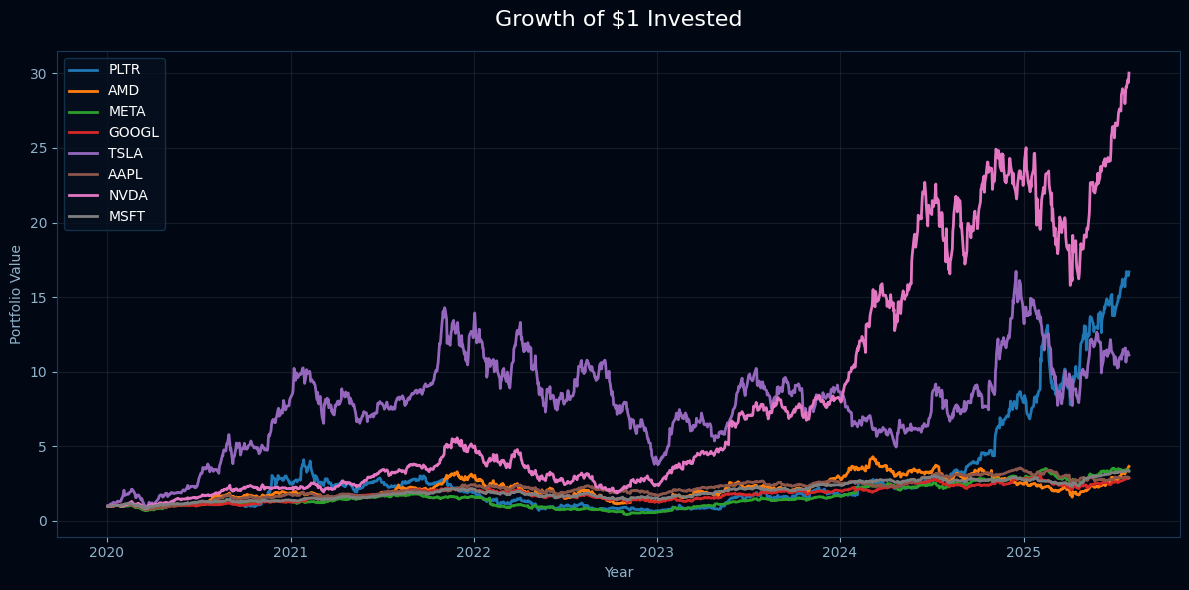

In [11]:
# cumulative returns

cumulative_returns = (1 + daily_returns).cumprod()

plt.figure(figsize=(12, 6))

ax = plt.gca()

ax.set_facecolor("#020714")
plt.gcf().patch.set_facecolor("#020714")

for company in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[company],
        label=company,
        linewidth=2
    )

plt.title(
    "Growth of $1 Invested",
    color="white",
    fontsize=16,
    pad=18
)

plt.xlabel(
    "Year",
    color="#8fb3c9"
)

plt.ylabel(
    "Portfolio Value",
    color="#8fb3c9"
)

plt.tick_params(colors="#8fb3c9")

for spine in ax.spines.values():
    spine.set_color("#173a55")

plt.grid(alpha=0.12)

plt.legend(
    facecolor="#06101f",
    edgecolor="#173a55",
    labelcolor="white"
)

plt.tight_layout()

plt.savefig(
    "../docs/growth_of_1.png",
    dpi=220,
    bbox_inches="tight",
    facecolor="#020714"
)

plt.show()

In [19]:
import plotly.graph_objects as go

fig = go.Figure()

for company in cumulative_returns.columns:
    fig.add_trace(
        go.Scatter(
            x=cumulative_returns.index,
            y=cumulative_returns[company],
            mode="lines",
            name=company,
            line=dict(width=3),
            hovertemplate=
                "<b>%{fullData.name}</b><br>" +
                "Date: %{x|%b %Y}<br>" +
                "Portfolio Value: %{y:.2f}×<extra></extra>"
        )
    )

fig.update_layout(
    title="Growth of $1 Invested (Interactive)",
    template="plotly_dark",
    hovermode="x unified",
    height=600,

    paper_bgcolor="#020714",
    plot_bgcolor="#020714",

    font=dict(
        family="Space Grotesk",
        color="white"
    ),

    title_font=dict(size=24),

    legend=dict(
        bgcolor="rgba(0,0,0,0)",
        borderwidth=0
    ),

    margin=dict(
        l=50,
        r=40,
        t=70,
        b=50
    )
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="rgba(255,255,255,0.08)"
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="rgba(255,255,255,0.08)",
    title="Portfolio Value"
)

fig.show()

In [20]:
fig.write_html(
    "../docs/growth_interactive.html",
    include_plotlyjs="cdn",
    full_html=True
)

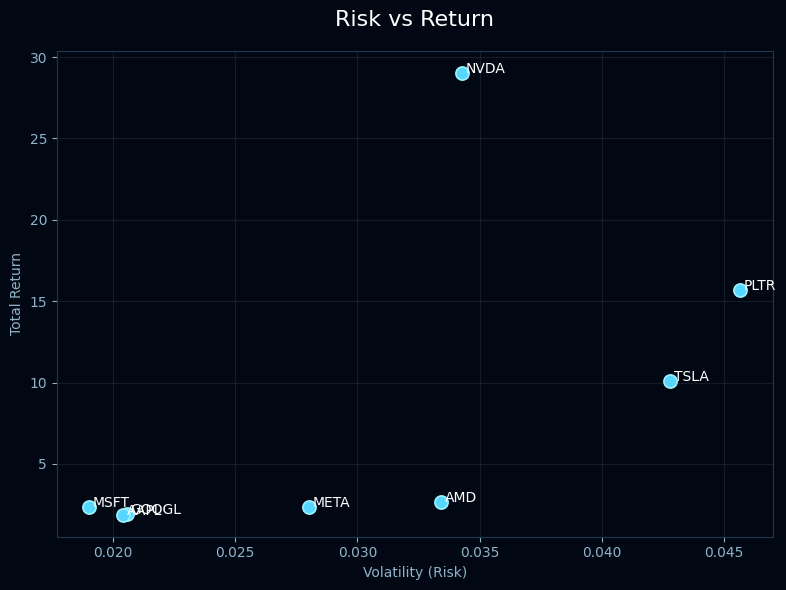

In [13]:
plt.figure(figsize=(8,6))

ax = plt.gca()

ax.set_facecolor("#020714")
plt.gcf().patch.set_facecolor("#020714")

plt.scatter(
    summary["Volatility"],
    summary["Total Return"],
    s=90,
    color="#55d7ff",
    edgecolors="#9cf3ff",
    linewidth=1.2
)

for ticker in summary.index:
    plt.text(
        summary.loc[ticker, "Volatility"] + 0.00015,
        summary.loc[ticker, "Total Return"],
        ticker,
        fontsize=10,
        color="white"
    )

plt.title(
    "Risk vs Return",
    color="white",
    fontsize=16,
    pad=18
)

plt.xlabel(
    "Volatility (Risk)",
    color="#8fb3c9"
)

plt.ylabel(
    "Total Return",
    color="#8fb3c9"
)

plt.tick_params(colors="#8fb3c9")

for spine in ax.spines.values():
    spine.set_color("#173a55")

plt.grid(alpha=0.12)

plt.tight_layout()

plt.savefig(
    "../docs/risk_vs_return.png",
    dpi=220,
    bbox_inches="tight",
    facecolor="#020714"
)

plt.show()

In [22]:
fig_risk = go.Figure()

fig_risk.add_trace(
    go.Scatter(
        x=summary["Volatility"],
        y=summary["Total Return"],
        mode="markers+text",
        text=summary.index,
        textposition="top center",
        marker=dict(
            size=12,
            color="#55d7ff",
            line=dict(
                color="#9cf3ff",
                width=1
            )
        ),
        hovertemplate=
            "<b>%{text}</b><br>" +
            "Volatility: %{x:.3f}<br>" +
            "Total Return: %{y:.2f}×<extra></extra>"
    )
)

fig_risk.update_layout(
    title="Risk vs Return (Interactive)",
    template="plotly_dark",
    height=600,
    paper_bgcolor="#020714",
    plot_bgcolor="#020714",
    font=dict(color="white"),
    xaxis_title="Volatility (Risk)",
    yaxis_title="Total Return"
)

fig_risk.show()

In [23]:
fig_risk.write_html(
    "../docs/risk_interactive.html",
    include_plotlyjs="cdn",
    full_html=True
)

In [14]:
tickers = [
    "AAPL",
    "MSFT",
    "NVDA",
    "GOOGL",
    "META",
    "TSLA",
    "AMD",
    "PLTR"
]

In [16]:
drawdowns = {}

for ticker in stock_data.columns.levels[0]:
    prices = stock_data[ticker]["Close"].dropna()

    running_max = prices.cummax()

    drawdown = (prices - running_max) / running_max

    drawdowns[ticker] = drawdown.min()

drawdown_df = pd.DataFrame.from_dict(
    drawdowns,
    orient="index",
    columns=["Maximum Drawdown"]
)

drawdown_df = drawdown_df.sort_values("Maximum Drawdown")

drawdown_df

,Maximum Drawdown
PLTR,-0.846154
META,-0.767361
TSLA,-0.736322
NVDA,-0.663351
AMD,-0.654499
GOOGL,-0.443200
MSFT,-0.371485
AAPL,-0.333605


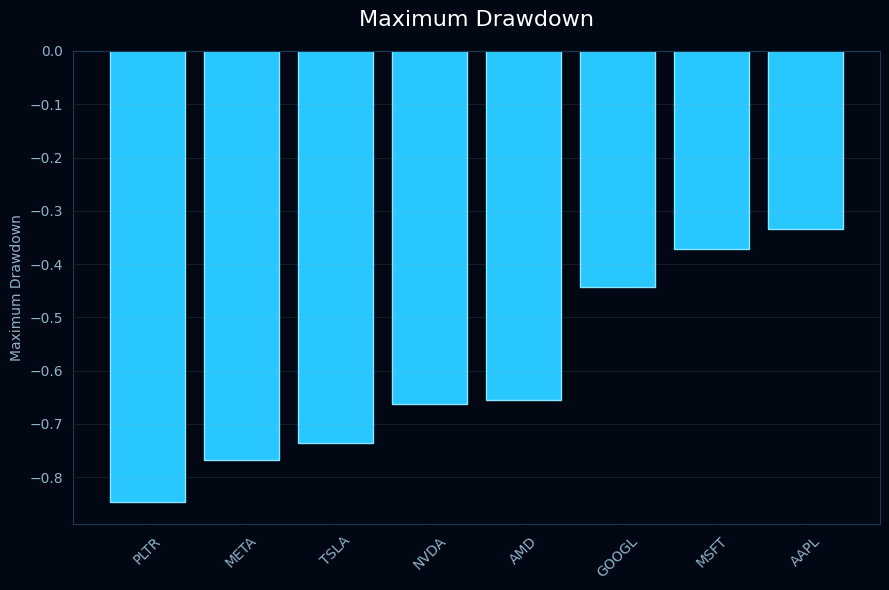

In [17]:
plt.figure(figsize=(9,6))

ax = plt.gca()

ax.set_facecolor("#020714")
plt.gcf().patch.set_facecolor("#020714")

plt.bar(
    drawdown_df.index,
    drawdown_df["Maximum Drawdown"],
    color="#29c7ff",
    edgecolor="#8be7ff",
    linewidth=1
)

plt.title(
    "Maximum Drawdown",
    color="white",
    fontsize=16,
    pad=18
)

plt.ylabel(
    "Maximum Drawdown",
    color="#8fb3c9"
)

plt.xticks(
    rotation=45,
    color="#8fb3c9"
)

plt.yticks(
    color="#8fb3c9"
)

for spine in ax.spines.values():
    spine.set_color("#173a55")

plt.grid(
    axis="y",
    alpha=0.12
)

plt.tight_layout()

plt.savefig(
    "../docs/maximum_drawdown.png",
    dpi=220,
    bbox_inches="tight",
    facecolor="#020714"
)

plt.show()

In [24]:
fig_drawdown = go.Figure()

fig_drawdown.add_trace(
    go.Bar(
        x=drawdown_df.index,
        y=drawdown_df["Maximum Drawdown"],
        marker_color="#35c8ff",
        marker_line_color="#9cefff",
        marker_line_width=1,
        hovertemplate=
            "<b>%{x}</b><br>" +
            "Maximum Drawdown: %{y:.1%}<extra></extra>"
    )
)

fig_drawdown.update_layout(
    title="Maximum Drawdown (Interactive)",
    template="plotly_dark",
    height=600,
    paper_bgcolor="#020714",
    plot_bgcolor="#020714",
    font=dict(color="white"),
    xaxis_title="Company",
    yaxis_title="Maximum Drawdown"
)

fig_drawdown.show()

In [25]:
fig_drawdown.write_html(
    "../docs/drawdown_interactive.html",
    include_plotlyjs="cdn",
    full_html=True
)

In [ ]:
summary.to_csv("../data/processed/summary_statistics.csv")

print("summary statistics saved!")

summary statistics saved!
